# Lorenz63 Pretrained Model Prediction Cookbook

This notebook loads a trained Lorenz63 Neural ODE checkpoint, runs trajectory prediction from the true initial state, and compares the learned trajectory with the reference Lorenz63 data.

It also compares the learned structured linear component and learned nonlinear residual component against the actual Lorenz63 model:

$$f(x) = Ax + G(x), \quad G(x, y, z) = [0, -xz, xy].$$

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.models import (
    build_lorenz63_model,
    lorenz63_linear_matrix,
    true_lorenz63_residual,
)

plt.rcParams.update({"figure.dpi": 120})
repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

The notebook will use the first existing checkpoint in `CHECKPOINT_CANDIDATES`. You can replace `CHECKPOINT_PATH` manually if you want a different pretrained model.

In [2]:
DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"
OUTPUT_DIR = repo_root / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_CANDIDATES = [
    OUTPUT_DIR / "lorenz63_bilinear_graph" / "lorenz63_bilinear_graph_10-28-2.7_1-1-2.pt",
    OUTPUT_DIR / "lorenz63_bilinear_graph_cookbook.pt",
    OUTPUT_DIR / "lorenz63_bilinear_graph_model.pt",
]
CHECKPOINT_PATH = next((path for path in CHECKPOINT_CANDIDATES if path.exists()), CHECKPOINT_CANDIDATES[0])

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
INITIAL_INDEX = 1000
ROLLOUT_STEPS = 4000
SAVE_FIGURES = True

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")
print(f"checkpoint: {CHECKPOINT_PATH}")

device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz
checkpoint: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph/lorenz63_bilinear_graph_10-28-2.7_1-1-2.pt


## Load Reference Trajectory

In [3]:
archive = np.load(DATA_PATH)
t = archive["t"].astype(np.float32)
states_np = archive["states"].astype(np.float32) if "states" in archive.files else np.stack(
    [archive["x"], archive["y"], archive["z"]], axis=-1
).astype(np.float32)
print(archive.files)
sigma = float(archive["sigma"])
rho = float(archive["rho"])
beta = float(archive["beta"])
dt = float(np.mean(np.diff(t)))

if INITIAL_INDEX < 0 or INITIAL_INDEX >= len(t) - 1:
    raise ValueError(f"INITIAL_INDEX must be in [0, {len(t) - 2}], got {INITIAL_INDEX}")

n_rollout = min(ROLLOUT_STEPS, len(t) - INITIAL_INDEX - 1)
t_rollout = t[INITIAL_INDEX : INITIAL_INDEX + n_rollout + 1]
true_states = torch.from_numpy(states_np[INITIAL_INDEX : INITIAL_INDEX + n_rollout + 1]).to(DEVICE)
initial_state = true_states[0]

print(f"sigma={sigma}, rho={rho}, beta={beta}, dt={dt}")
print(f"initial index: {INITIAL_INDEX}, initial time: {float(t_rollout[0])}")
print(f"initial state: {initial_state.detach().cpu().tolist()}")
print(f"trajectory samples used: {n_rollout + 1}")

['t', 'x', 'y', 'z', 'states', 'sigma', 'rho', 'beta']
sigma=10.0, rho=28.0, beta=2.7, dt=0.009999999776482582
initial index: 1000, initial time: 10.0
initial state: [-4.477860450744629, -4.008039951324463, 23.064987182617188]
trajectory samples used: 4001


## Load Pretrained Model

In [4]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
params = checkpoint.get("params", {})
state_dict = checkpoint["model_state_dict"]
state_keys = set(state_dict)

MODEL_NAME = params.get("model_name", "polynomial")
SIGMA_INIT = float(params.get("sigma_init", sigma))
RHO_INIT = float(params.get("rho_init", rho))
BETA_INIT = float(params.get("beta_init", beta))
HIDDEN_DIM = int(params.get("hidden_dim", 64))
N_HIDDEN_LAYERS = int(params.get("n_hidden_layers", 2))

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)
legacy_linear = any(key.endswith("linear.coefficients") for key in state_keys)
current_linear = any(key.endswith("linear.parameters_lorenz") for key in state_keys)

model_expects_current_linear = (
    hasattr(model, "linear")
    and hasattr(model.linear, "parameters_lorenz")
)

if current_linear and not model_expects_current_linear:
    raise RuntimeError(
        "This checkpoint uses linear.parameters_lorenz, but the notebook "
        "kernel is using an older model class. Restart the kernel and rerun "
        "the notebook from the top."
    )

if legacy_linear:
    raise RuntimeError(
        "This checkpoint uses the old linear.coefficients parameterization. "
        "Retrain and save a new checkpoint with the current models.py."
    )

if hasattr(model, "linear") and not current_linear:
    raise RuntimeError(
        "This checkpoint does not contain linear.parameters_lorenz. Check that "
        "you are loading a checkpoint trained with the current models.py."
    )

model.load_state_dict(state_dict)
model.eval()

print(f"loaded model: {MODEL_NAME}")
print(f"checkpoint params: {params}")


loaded model: bilinear_graph


checkpoint params: {'model_name': 'bilinear_graph', 'sigma_init': 1, 'rho_init': 1, 'beta_init': 2, 'hidden_dim': 32, 'n_hidden_layers': 1, 'learned_A': tensor([[-9.9770,  9.9770,  0.0000],
        [27.9011, -1.0000,  0.0000],
        [ 0.0000,  0.0000, -2.6914]], device='cuda:0')}


## Roll Out The Learned Dynamics

The trained model returns $dx/dt$. The helper below integrates the learned ODE with RK4 so the predicted trajectory can be compared against the reference trajectory.

In [5]:
@torch.no_grad()
def rk4_rollout(model, initial_state, dt, n_steps):
    model.eval()
    states = [initial_state]
    current = initial_state

    for _ in range(n_steps):
        k1 = model(current.unsqueeze(0)).squeeze(0)
        k2 = model((current + 0.5 * dt * k1).unsqueeze(0)).squeeze(0)
        k3 = model((current + 0.5 * dt * k2).unsqueeze(0)).squeeze(0)
        k4 = model((current + dt * k3).unsqueeze(0)).squeeze(0)
        current = current + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        states.append(current)

    return torch.stack(states, dim=0)


pred_states = rk4_rollout(model, initial_state, dt, n_rollout)
trajectory_rmse = torch.sqrt(torch.mean((pred_states - true_states) ** 2, dim=0)).detach().cpu()
overall_trajectory_rmse = torch.sqrt(torch.mean((pred_states - true_states) ** 2)).item()

print(f"overall trajectory RMSE: {overall_trajectory_rmse:.6f}")
print(f"component trajectory RMSE [x, y, z]: {trajectory_rmse.tolist()}")

overall trajectory RMSE: 11.270412
component trajectory RMSE [x, y, z]: [10.94304370880127, 12.333704948425293, 10.44969367980957]


## Trajectory Comparison

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_predicted_trajectory_3d.png


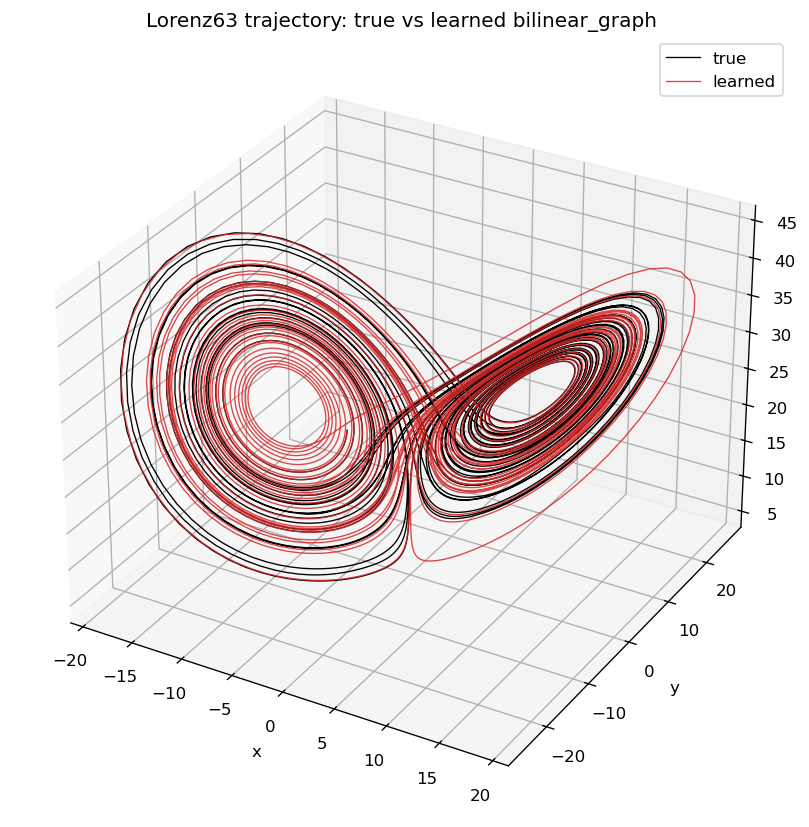

In [6]:
true_np = true_states.detach().cpu().numpy()
pred_np = pred_states.detach().cpu().numpy()

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(true_np[:, 0], true_np[:, 1], true_np[:, 2], lw=0.8, label="true", color="black")
ax.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], lw=0.8, label="learned", color="tab:red", alpha=0.85)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(f"Lorenz63 trajectory: true vs learned {MODEL_NAME}")
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_predicted_trajectory_3d.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_predicted_timeseries.png


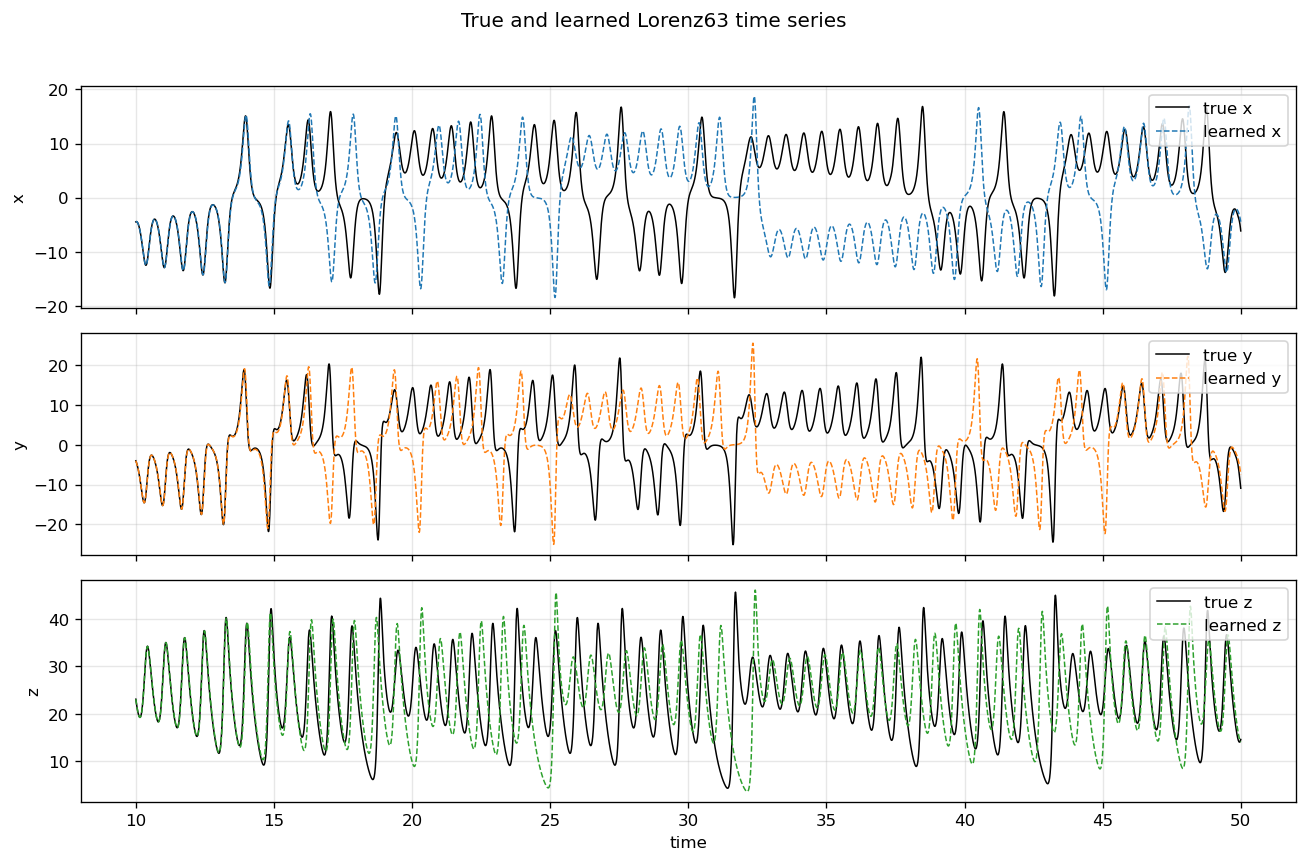

In [7]:
component_names = ["x", "y", "z"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for idx, (name, color) in enumerate(zip(component_names, colors)):
    axes[idx].plot(t_rollout, true_np[:, idx], color="black", lw=0.9, label=f"true {name}")
    axes[idx].plot(t_rollout, pred_np[:, idx], color=color, lw=0.9, linestyle="--", label=f"learned {name}")
    axes[idx].set_ylabel(name)
    axes[idx].legend(loc="upper right")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle("True and learned Lorenz63 time series", y=1.02)
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_predicted_timeseries.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

## Compare Learned Linear Parameters

For structured models, `model.A` is the learned linear Lorenz matrix. The true matrix is built from the data parameters.

In [8]:
A_true = lorenz63_linear_matrix(sigma=sigma, rho=rho, beta=beta).to(DEVICE)

if hasattr(model, "A"):
    A_learned = model.A.detach()
    A_error = A_learned - A_true

    print("true A:")
    print(A_true.detach().cpu().numpy())
    print("learned A:")
    print(A_learned.detach().cpu().numpy())
    print("learned - true A:")
    print(A_error.detach().cpu().numpy())
else:
    A_learned = None
    print(f"{MODEL_NAME} does not expose a structured learned A matrix.")

true A:
[[-10.   10.    0. ]
 [ 28.   -1.    0. ]
 [  0.    0.   -2.7]]
learned A:
[[-9.977007   9.977007   0.       ]
 [27.901075  -1.         0.       ]
 [ 0.         0.        -2.6913671]]
learned - true A:
[[ 0.02299309 -0.02299309  0.        ]
 [-0.09892464  0.          0.        ]
 [ 0.          0.          0.0086329 ]]


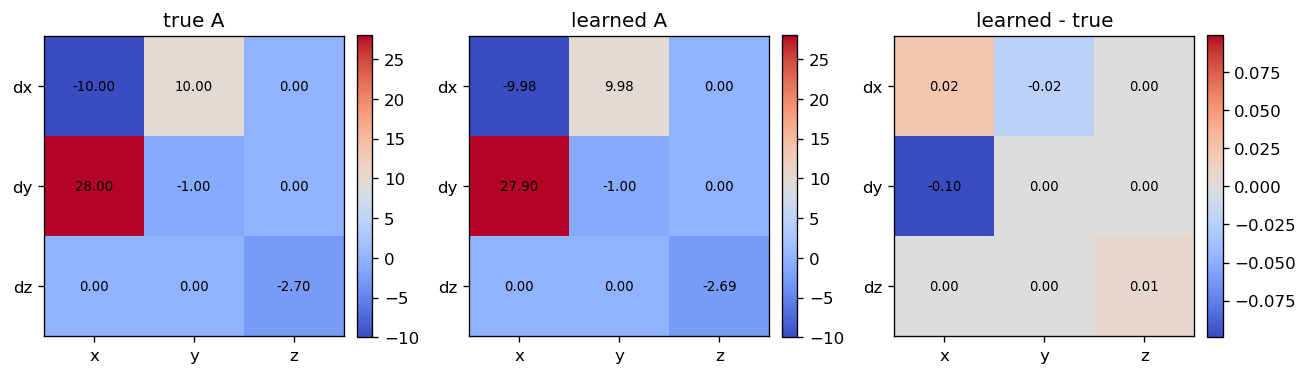

In [9]:
if A_learned is not None:
    mats = [A_true.detach().cpu().numpy(), A_learned.detach().cpu().numpy(), A_error.detach().cpu().numpy()]
    titles = ["true A", "learned A", "learned - true"]
    vmin = min(mat.min() for mat in mats[:2])
    vmax = max(mat.max() for mat in mats[:2])
    err_abs = np.max(np.abs(mats[2]))

    fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
    for idx, ax in enumerate(axes):
        if idx < 2:
            im = ax.imshow(mats[idx], cmap="coolwarm", vmin=vmin, vmax=vmax)
        else:
            im = ax.imshow(mats[idx], cmap="coolwarm", vmin=-err_abs, vmax=err_abs)
        ax.set_title(titles[idx])
        ax.set_xticks([0, 1, 2], labels=["x", "y", "z"])
        ax.set_yticks([0, 1, 2], labels=["dx", "dy", "dz"])
        for row in range(3):
            for col in range(3):
                ax.text(col, row, f"{mats[idx][row, col]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()

## Compare Linear And Nonlinear Components

The true split is:

$$Ax = [\sigma(y-x), \rho x-y, -\beta z],$$

$$G(x, y, z) = [0, -xz, xy].$$

Structured residual models expose `model.linear` and `model.residual_tendency`. The `true_*` quantities below are always computed from the loaded reference trajectory. The `learned_*` quantities are computed from the model's autonomous rollout states. For pure machine-learning models without explicit component attributes, the learned nonlinear component is evaluated from the Lorenz nonlinear formula at the model-predicted states and the learned linear component is inferred from the learned total tendency at those same predicted states.


In [10]:
@torch.no_grad()
def evaluate_components(model, x_true):
    true_linear = torch.matmul(x_true, A_true.T)
    true_residual = true_lorenz63_residual(x_true)
    true_tendency = true_linear + true_residual
    learned_tendency = model(x_true)

    has_structured_split = hasattr(model, "linear") and hasattr(model, "residual_tendency")
    if has_structured_split:
        learned_linear = model.linear(x_true)
        learned_residual = model.residual_tendency(x_true)
        split_source = "model components"
    else:
        x = x_true[:, 0]
        y = x_true[:, 1]
        z = x_true[:, 2]
        learned_residual = torch.stack(
            [torch.zeros_like(x), -x * z, x * y],
            dim=1,
        )
        learned_linear = learned_tendency - learned_residual
        split_source = "inferred from learned tendency and Lorenz nonlinear terms"

    return true_linear, true_residual, true_tendency, learned_linear, learned_residual, learned_tendency, split_source


# Component diagnostics are teacher-forced: true and learned terms are both evaluated at x_true.
component_true_states = true_states
(
    true_linear,
    true_residual,
    true_tendency,
    learned_linear,
    learned_residual,
    learned_tendency,
    split_source,
) = evaluate_components(model, component_true_states)

print(f"component split source: {split_source}")
tendency_rmse = torch.sqrt(torch.mean((learned_tendency - true_tendency) ** 2, dim=0)).detach().cpu()
print(f"tendency RMSE [dx/dt, dy/dt, dz/dt]: {tendency_rmse.tolist()}")

linear_rmse = torch.sqrt(torch.mean((learned_linear - true_linear) ** 2, dim=0)).detach().cpu()
print(f"linear component RMSE: {linear_rmse.tolist()}")

residual_rmse = torch.sqrt(torch.mean((learned_residual - true_residual) ** 2, dim=0)).detach().cpu()
print(f"nonlinear residual RMSE: {residual_rmse.tolist()}")


component split source: model components
tendency RMSE [dx/dt, dy/dt, dz/dt]: [0.0949997827410698, 0.20244811475276947, 0.2009708285331726]
linear component RMSE: [0.0949997827410698, 0.7898417115211487, 0.21711771190166473]
nonlinear residual RMSE: [0.0, 0.7781074643135071, 0.26249757409095764]


saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_learned_linear_components.png


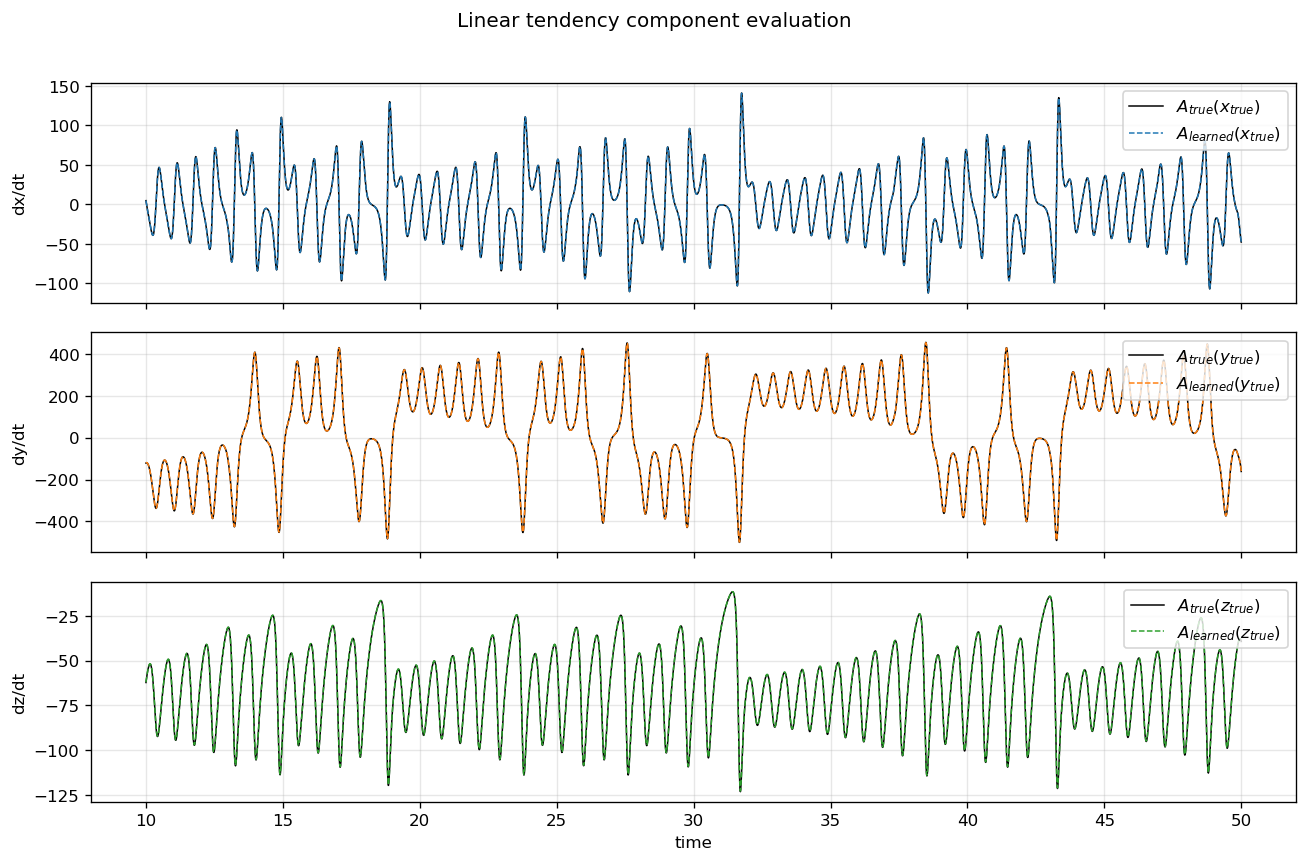

In [11]:
true_linear_np = true_linear.detach().cpu().numpy()
learned_linear_np = learned_linear.detach().cpu().numpy()
linear_true_label = "A_true(x_true)"
linear_learned_label = "A_learned(x_true)"

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for idx, name in enumerate(["dx/dt", "dy/dt", "dz/dt"]):
    state_name = ["x", "y", "z"][idx]
    axes[idx].plot(t_rollout, true_linear_np[:, idx], color="black", lw=0.9, label=rf"$A_{{true}}({state_name}_{{true}})$")
    axes[idx].plot(t_rollout, learned_linear_np[:, idx], color=colors[idx], lw=0.9, linestyle="--", label=rf"$A_{{learned}}({state_name}_{{true}})$")
    axes[idx].set_ylabel(name)
    axes[idx].legend(loc="upper right")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle(f"Linear tendency component evaluation", y=1.02)
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_learned_linear_components.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_learned_residual_components.png


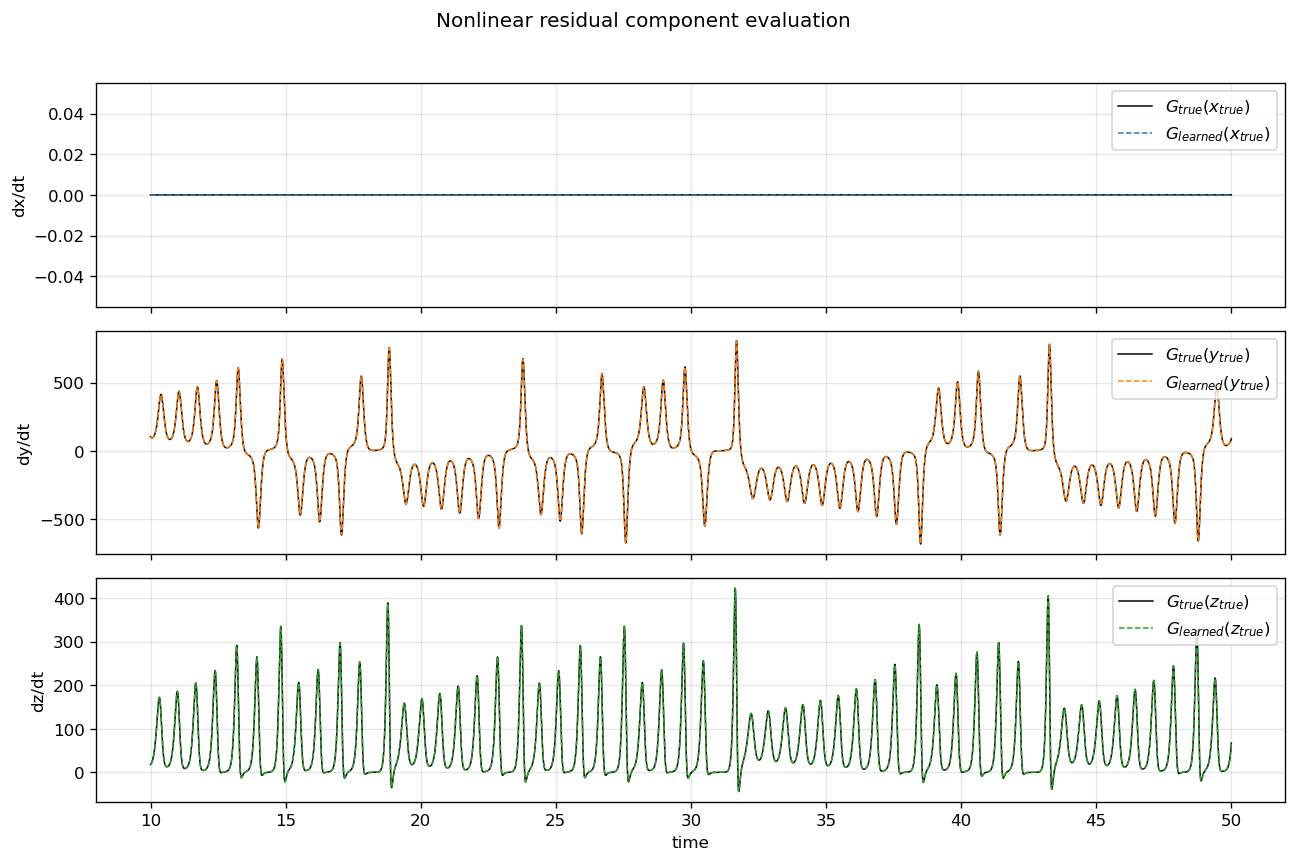

In [12]:
true_residual_np = true_residual.detach().cpu().numpy()
learned_residual_np = learned_residual.detach().cpu().numpy()
residual_true_label = "G_true(x_true)"
residual_learned_label = "G_learned(x_true)"

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for idx, name in enumerate(["dx/dt", "dy/dt", "dz/dt"]):
    state_name = ["x", "y", "z"][idx]
    axes[idx].plot(t_rollout, true_residual_np[:, idx], color="black", lw=0.9, label=rf"$G_{{true}}({state_name}_{{true}})$")
    axes[idx].plot(t_rollout, learned_residual_np[:, idx], color=colors[idx], lw=0.9, linestyle="--", label=rf"$G_{{learned}}({state_name}_{{true}})$")
    axes[idx].set_ylabel(name)
    axes[idx].legend(loc="upper right")
    axes[idx].grid(alpha=0.3)

axes[-1].set_xlabel("time")
fig.suptitle(f"Nonlinear residual component evaluation", y=1.02)
fig.tight_layout()

if SAVE_FIGURES:
    path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_learned_residual_components.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved {path}")

plt.show()

## Learned Component Scatter

These scatter plots show whether the learned or inferred component values agree with the true linear and nonlinear component values along the reference trajectory. Perfect agreement lies on the dashed diagonal.

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_learned_linear_parity.png


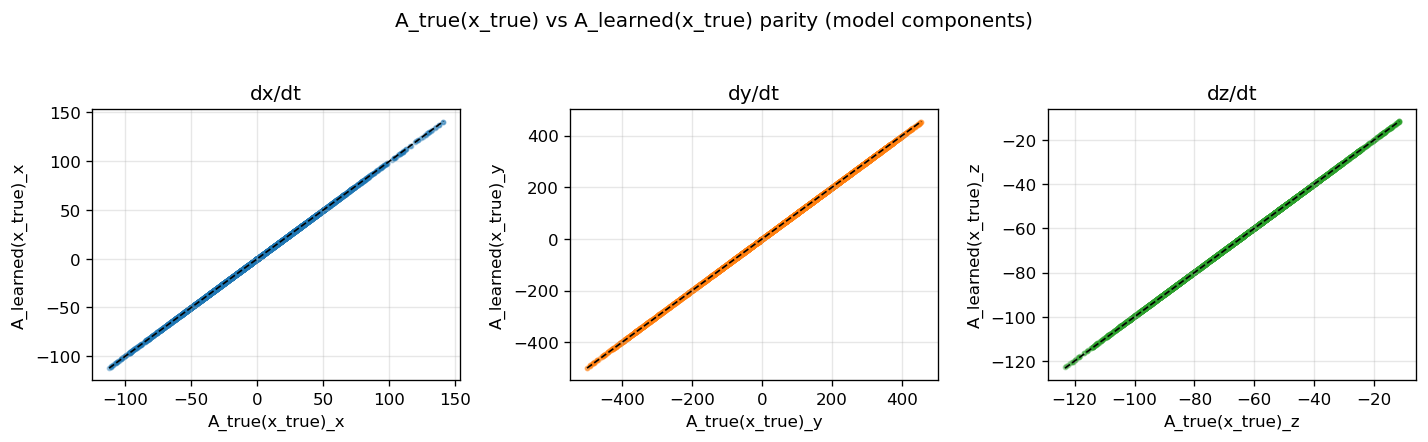

saved /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/lorenz63_bilinear_graph_learned_residual_parity.png


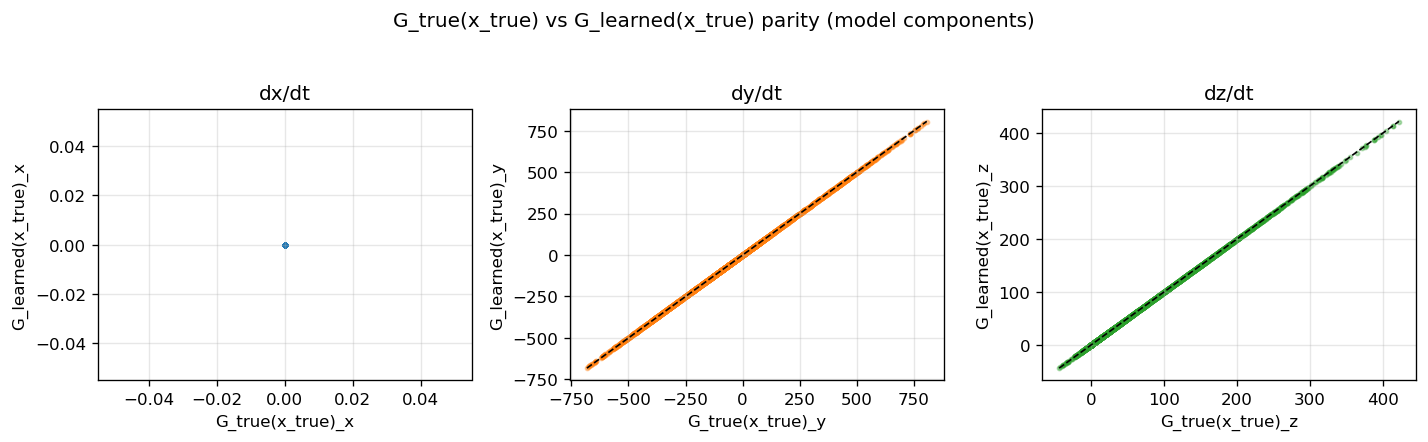

In [13]:
def _component_parity_plot(true_component, learned_component, true_label, learned_label, filename_suffix):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for idx, (ax, name) in enumerate(zip(axes, ["dx/dt", "dy/dt", "dz/dt"])):
        xvals = true_component[:, idx]
        yvals = learned_component[:, idx]
        ax.scatter(xvals, yvals, s=6, alpha=0.35, color=colors[idx])
        lo = min(xvals.min(), yvals.min())
        hi = max(xvals.max(), yvals.max())
        ax.plot([lo, hi], [lo, hi], color="black", lw=1.0, linestyle="--")
        ax.set_title(name)
        state_name = ["x", "y", "z"][idx]
        ax.set_xlabel(f"{true_label}_{state_name}")
        ax.set_ylabel(f"{learned_label}_{state_name}")
        ax.grid(alpha=0.3)

    fig.suptitle(f"{true_label} vs {learned_label} parity ({split_source})", y=1.04)
    fig.tight_layout()

    if SAVE_FIGURES:
        path = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_{filename_suffix}_parity.png"
        fig.savefig(path, dpi=200, bbox_inches="tight")
        print(f"saved {path}")

    plt.show()


_component_parity_plot(true_linear_np, learned_linear_np, linear_true_label, linear_learned_label, "learned_linear")
_component_parity_plot(true_residual_np, learned_residual_np, residual_true_label, residual_learned_label, "learned_residual")


## Statistics Comparison

Compare mean, variance, and skewness between the learned and actual state variables and tendencies.


In [14]:
def _sample_stats(values):
    values = np.asarray(values, dtype=np.float64)
    mean = values.mean(axis=0)
    variance = values.var(axis=0)
    std = np.sqrt(variance)
    centered = values - mean
    skewness = np.divide(
        np.mean(centered ** 3, axis=0),
        std ** 3,
        out=np.zeros_like(mean),
        where=std > 0,
    )
    return {"mean": mean, "variance": variance, "skewness": skewness}


def _print_stats_comparison(title, names, actual_values, learned_values):
    actual_stats = _sample_stats(actual_values)
    learned_stats = _sample_stats(learned_values)

    print(title)
    print(f"{'variable':<8} {'statistic':<10} {'actual':>14} {'learned':>14} {'learned-actual':>16}")
    print("-" * 66)
    for idx, name in enumerate(names):
        for stat_name in ["mean", "variance", "skewness"]:
            actual = actual_stats[stat_name][idx]
            learned = learned_stats[stat_name][idx]
            print(f"{name:<8} {stat_name:<10} {actual:>14.6g} {learned:>14.6g} {learned - actual:>16.6g}")
    print()


true_tendency_np = true_tendency.detach().cpu().numpy()
learned_tendency_np = learned_tendency.detach().cpu().numpy()

_print_stats_comparison(
    "State statistics: actual vs learned",
    ["X", "Y", "Z"],
    true_np,
    pred_np,
)
_print_stats_comparison(
    "Tendency statistics: actual vs learned",
    ["dX", "dY", "dZ"],
    true_tendency_np,
    learned_tendency_np,
)


State statistics: actual vs learned
variable statistic          actual        learned   learned-actual
------------------------------------------------------------------
X        mean              1.80252      -0.269173          -2.0717
X        variance          60.4996        63.7254          3.22583
X        skewness        -0.412748      0.0552515            0.468
Y        mean               1.7975      -0.269416         -2.06691
Y        variance          77.6542        80.4213          2.76711
Y        skewness         -0.39596      0.0474515         0.443411
Z        mean              23.7033        23.7301        0.0267934
Z        variance           70.676        70.1523        -0.523692
Z        skewness         0.105541      0.0672594       -0.0382814

Tendency statistics: actual vs learned
variable statistic          actual        learned   learned-actual
------------------------------------------------------------------
dX       mean           -0.0502621     -0.0501465    